# amaliemulator-customobj
adding PCA (pcann) layer and Weighted Mean Squared Error loss function custom objects

In [2]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers
from scripts.WMSE import WMSE
from scripts.WMSE import WMSE_metric
from scripts.PCANN import PCANN

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

physical_devices = tf.config.list_physical_devices("GPU")

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n" + " - GPU0: " + str(gpu0usage) + "B\n")

2024-07-03 15:59:55.369454: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-03 15:59:55.369488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-03 15:59:55.370511: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-07-03 15:59:55.375557: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-03 15:59:55.947019: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-07-03 15:59:56.485158: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18226 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


## data prep
usually called 'data augmentation' in the ML community, but I think referees will have questions if you say "we augmented the data to make our network train better" - this is where we get our data ready for a neural network to start training.\
usually consists of:
- check and clean data to remove NaNs etc
- define our inputs and outputs for training
- scale data for better network training
- split into our *train*, *validation*, and *test* sets

### inps, outs and normalise

In [3]:
df_full = pd.read_hdf(
    "/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/barbie_nu.h5", key="df"
)  ## edit for your grid!!

#### define inputs
inputs = ["initial_mass", "initial_Zinit", "initial_Yinit", "initial_MLT", "star_age"]

#### define outputs
classical_outputs = ["radius", "luminosity", "surface_Z"]
astero_outputs = [f"nu_0_{i+1}" for i in range(10, 30)]  # 10 modes for now

outputs = classical_outputs + astero_outputs

df = df_full[inputs + outputs]

df_norm = (df - df.min()) / (df.max() - df.min())

## check df_norm.describe looks reasonable (min=0, max=1):
df_norm.describe()

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,surface_Z,nu_0_11,nu_0_12,...,nu_0_21,nu_0_22,nu_0_23,nu_0_24,nu_0_25,nu_0_26,nu_0_27,nu_0_28,nu_0_29,nu_0_30
count,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,...,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06,1.160882e+06
mean,6.368254e-01,2.946521e-01,4.784779e-01,5.010575e-01,3.297499e-01,3.507220e-01,1.021305e-01,2.687424e-01,3.810576e-01,3.812796e-01,...,3.819317e-01,3.821951e-01,3.824622e-01,3.827019e-01,3.829539e-01,3.831615e-01,3.833545e-01,3.835044e-01,3.836254e-01,3.837209e-01
std,2.377429e-01,2.666994e-01,2.869593e-01,2.884864e-01,2.497901e-01,1.698813e-01,8.955022e-02,2.483849e-01,1.693398e-01,1.693985e-01,...,1.687081e-01,1.686277e-01,1.685631e-01,1.685077e-01,1.684881e-01,1.684806e-01,1.684960e-01,1.685187e-01,1.685501e-01,1.685865e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.660000e-01,6.466661e-02,2.287215e-01,2.515570e-01,1.272709e-01,2.308146e-01,3.860117e-02,5.064833e-02,2.579484e-01,2.580865e-01,...,2.599090e-01,2.602957e-01,2.607057e-01,2.610569e-01,2.613862e-01,2.616421e-01,2.618585e-01,2.620161e-01,2.621194e-01,2.621812e-01
50%,6.700000e-01,2.100469e-01,4.667237e-01,5.003053e-01,2.730798e-01,3.216508e-01,7.600686e-02,1.953707e-01,3.765407e-01,3.769365e-01,...,3.780518e-01,3.784121e-01,3.787779e-01,3.791128e-01,3.794663e-01,3.797659e-01,3.800539e-01,3.802760e-01,3.804565e-01,3.806067e-01
75%,8.320000e-01,4.770009e-01,7.226768e-01,7.512517e-01,4.900688e-01,4.376292e-01,1.377703e-01,4.415408e-01,4.988499e-01,4.991281e-01,...,4.987463e-01,4.989045e-01,4.990806e-01,4.992358e-01,4.994514e-01,4.996293e-01,4.998312e-01,4.999951e-01,5.001446e-01,5.002782e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### perform pca operation
here we'll define the PCA components and means for our pca layer in the network\
we'll perform PCA with a user specified number of principle components on *just* the asteroseismic terms (individual modes)


#### test different numbers of PCA components to include
Compare explained variance ratio for different number of pca components, from 1 to len(astero_outs) (may take a while!)

Explained variance ratio with n_comps = 1 is 0.9999673518887737
Explained variance ratio with n_comps = 2 is 0.999997822406065
Explained variance ratio with n_comps = 3 is 0.9999992928796859
Explained variance ratio with n_comps = 4 is 0.9999996748311741
Explained variance ratio with n_comps = 5 is 0.9999997927126655
Explained variance ratio with n_comps = 6 is 0.9999998654461265
Explained variance ratio with n_comps = 7 is 0.9999999310240505
Explained variance ratio with n_comps = 8 is 0.9999999698859665
Explained variance ratio with n_comps = 9 is 0.9999999812887624
Explained variance ratio with n_comps = 10 is 0.9999999877842821
Explained variance ratio with n_comps = 11 is 0.9999999906224931
Explained variance ratio with n_comps = 12 is 0.999999992605038
Explained variance ratio with n_comps = 13 is 0.999999994155336
Explained variance ratio with n_comps = 14 is 0.9999999955374955
Explained variance ratio with n_comps = 15 is 0.9999999967030276
Explained variance ratio with n_comps

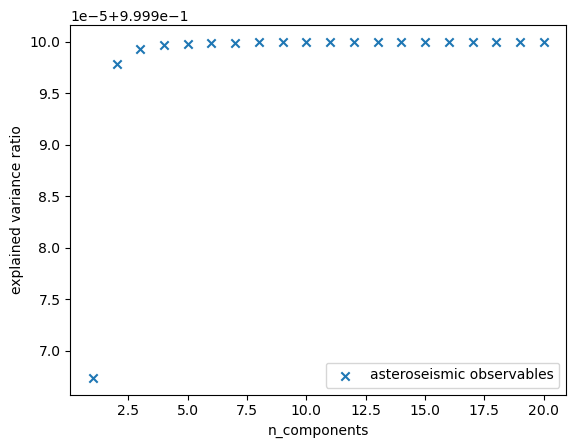

In [4]:
### define pca global vars
df_outs = df_full[astero_outputs]
seed = 42

### arrays for plot loop
astero_evr_arr = np.zeros(len(astero_outputs))
n_arr = np.arange(1, len(astero_outputs) + 1)


### plot loop
i = 0
for n in n_arr:
    pca = PCA(n_components=n, random_state=seed)
    pca.fit(df_outs)
    print(
        "Explained variance ratio with n_comps = "
        + str(n)
        + " is "
        + str(sum(pca.explained_variance_ratio_))
    )
    astero_evr_arr[i] = sum(pca.explained_variance_ratio_)
    i += 1

# plt.scatter(n_arr, classical_evr_arr, marker='+', label='classical observables')
plt.scatter(n_arr, astero_evr_arr, marker="x", label="asteroseismic observables")
plt.ylabel("explained variance ratio")
plt.xlabel("n_components")
plt.legend()

#### proceed with chosen n_components
set n_components here to the number of principle components to use when training\
choose number of components to train on - this becomes the new number of units in the final *dense* layer of astero tine\
then we slot in our PCANN layer (Inverse PCA operation) to project back to the full parameter space


In [5]:
#### define pca global vars
n_components = 20
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print(
    "Explained variance ratio with n_comps = "
    + str(n_components)
    + " is "
    + str(sum(pca.explained_variance_ratio_))
)

Explained variance ratio with n_comps = 20 is 1.0000000000000002


### define weights for WMSE loss function
here the "weights" will be the target uncertainty level we're seeking to achieve or surpass with our network\
we'll enter these in linear form, and then scale according do our data scaling approach from before


In [6]:
linear_unc_dict = {
    "radius": 0.01,
    "luminosity": 0.02,
    "surface_Z": 0.0001,
}

freq_unc = 0.1  #\muHz#
for i in range(10, 30):
    linear_unc_dict[f"nu_0_{i+1}"] = freq_unc

scaled_unc_dict = {}
for entry in list(linear_unc_dict.items()):
    scale_range = df_full[entry[0]].max() - df_full[entry[0]].min()
    scaled_unc_dict[entry[0]] = entry[1] / scale_range

scaled_weights = list(scaled_unc_dict.values())
scaled_weights

[0.006592324623627621,
 0.001314365342126306,
 0.001983529937417743,
 3.9693565622332914e-05,
 3.6759183416741456e-05,
 3.42314986212248e-05,
 3.2035158714830165e-05,
 3.0102838219008927e-05,
 2.840307139452832e-05,
 2.6889679630710047e-05,
 2.553350704839765e-05,
 2.430560832486589e-05,
 2.319012160910663e-05,
 2.2168965156982654e-05,
 2.1231886790990453e-05,
 2.037031752018185e-05,
 1.9573851468837797e-05,
 1.8837158375282807e-05,
 1.8151491763835202e-05,
 1.751327437671358e-05,
 1.691677569672874e-05,
 1.6358756451263894e-05,
 1.5835845794545387e-05]

### split into train/validate/test

In [7]:
#### train/test split with seed
seed = 42

df_train = df_norm.sample(frac=0.95, random_state=seed)
df_test = df_norm.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = (
    sklearn.model_selection.train_test_split(
        df_train[inputs], df_train[outputs], test_size=0.05, random_state=seed
    )
)

print("Training set: ", len(df_train_inputs))
print("Validation set: ", len(df_val_inputs))
print("Test set: ", len(df_test))

Training set:  1047696
Validation set:  55142
Test set:  58044


## training our network
here we'll use our *train* and *validation* sets to train our neural network and check for overfitting\
I'm using the tensorflow functional API here - while this is a little harder to understand than the sequential API, it's more versatile and will let us do fun things like branching the neural network architecture later on!\
This time I've dropped in my 'pitchfork' branching neural network architecture. Let me know if you need any explainations for this!

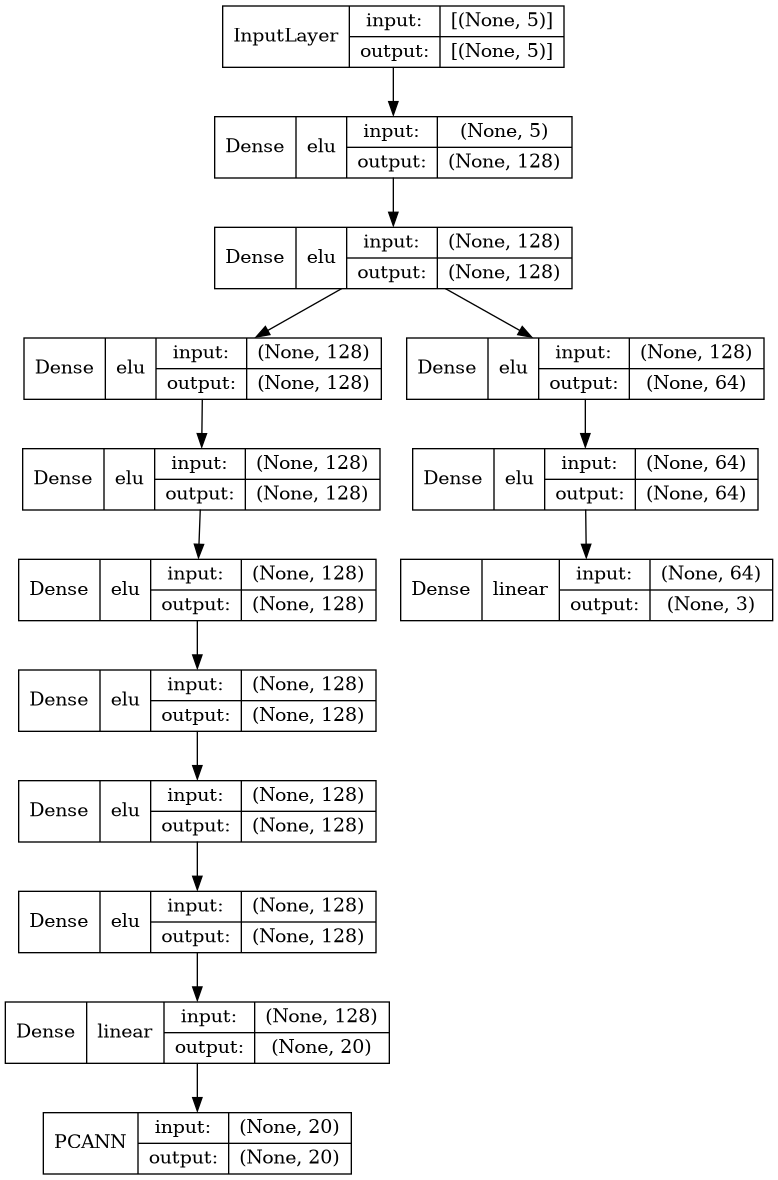

In [8]:
"""
        ________
_______/
       \________
| stem | tines |

"""

######## define architecture:
model_name = "pitchfork"

stem_dense_layers = 2  # number of dense layers in stem
stem_dense_units = 128  # neurons per dense layer in stem

ctine_dense_layers = 2  # number of dense layers in 'classicals' tine
ctine_dense_units = 64  # neurons per dense layer in 'classicals' tine

atine_dense_layers = 6  # number of dense layers in 'asteroseismic' tine
atine_dense_units = 128  # neurons per dense layer in 'asteroseismic' tine


######## stem
#### input
stem_input = keras.Input(shape=(len(inputs),))

for stem_dense_layer in range(stem_dense_layers):
    if stem_dense_layer == 0:
        stem = layers.Dense(stem_dense_units, activation="elu")(stem_input)
    else:
        stem = layers.Dense(stem_dense_units, activation="elu")(stem)

######## classical tine
#### dense layers
for ctine_dense_layer in range(ctine_dense_layers):
    if ctine_dense_layer == 0:
        ctine = layers.Dense(ctine_dense_units, activation="elu")(stem)
    else:
        ctine = layers.Dense(ctine_dense_units, activation="elu")(ctine)

#### output
ctine_out = layers.Dense(len(classical_outputs), name="classical_outs")(ctine)


######## astero tine
#### dense layers
for atine_dense_layer in range(atine_dense_layers):
    if atine_dense_layer == 0:
        atine = layers.Dense(atine_dense_units, activation="elu")(stem)
    else:
        atine = layers.Dense(atine_dense_units, activation="elu")(atine)

#### output
atine = layers.Dense(int(len(pca.components_)))(atine)
atine_out = PCANN(
    pca_comps=pca.components_, pca_mean=pca.mean_, name="asteroseismic_outs"
)(atine)

######## construct and fit
model = keras.Model(
    inputs=stem_input, outputs=[ctine_out, atine_out], name="tuning_fork"
)

######## plot model
keras.utils.plot_model(
    model,
    "figs/" + model_name + ".png",
    show_layer_activations=True,
    show_shapes=True,
    show_layer_names=False,
)

In [ ]:
######## compile and start training
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)


model.compile(loss=[WMSE(scaled_weights[:len(classical_outputs)]), WMSE(scaled_weights[len(classical_outputs):])], optimizer=optimizer)


#### fit model
## learning rate scheduler, decreases learning rate in-training for stability
def scheduler(epoch, lr):
    if lr < 1e-5:
        return lr
    else:
        return lr * tf.math.exp(-0.00006)


lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)

## tensorboard logging callback, to avoid having to rely on tensorflow readout

log_dir = f"/home/oxs235/datastorage/repos_data/ojscutt/amaliemulator/logs/fit/{model_name}"  # <-- enter your log directory here!

tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

# to use tensorboard:
# 1) open console in parent directory containing logs file (for above it'd be /home/oxs235/datastorage/repos_data/ojscutt/amaliemulator/)
# 2) run `tensorboard --logdir logs/fit --port=8874', set port to any open port not currently in use by jupyter
# 3) paste returned url into browser (for above it'd be `http://localhost:8874/')

# saving logs from different models in the same directory (e.g. logs/fit) under different model names means we can compare in one instance of tensorboard!

## checkpointing callback, to save copy of model during training at detected minima in validation loss

model_dir = f"/home/oxs235/datastorage/repos_data/ojscutt/amaliemulator/models/"  # <-- enter your models directory here!

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_dir + model_name + "_checkpoint.h5",  # define model name and directory
    monitor="val_loss",  # value to monitor
    save_best_only=True,  # overwrite worse models to avoid memory consumption
    save_freq="epoch",
)  # check val_loss every epoch


history = model.fit(
    df_train_inputs,
    [df_train_outputs[classical_outputs], df_train_outputs[astero_outputs]],
    validation_data=(
        df_val_inputs,
        [df_val_outputs[classical_outputs], df_val_outputs[astero_outputs]],
    ),
    batch_size=32768,
    verbose=0,
    epochs=100000,
    callbacks=[lr_callback, tb_callback, cp_callback],
    shuffle=True,
)

2024-07-03 16:00:44.921297: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-07-03 16:00:46.374263: I external/local_xla/xla/service/service.cc:168] XLA service 0x74f094e16250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-07-03 16:00:46.374284: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4500, Compute Capability 8.6
2024-07-03 16:00:46.378504: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-07-03 16:00:46.393319: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1720018846.458537  108299 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/s

## testing the network
this section is very rushed, the main thing is to remember to rescale your data (as the network will predict in the normalised space), and to predict on the test set that was taken out of the dataset before training!

In [ ]:
def unnorm(df_norm, df_min, df_max):
    df_unnorm = (df_norm * (df_max - df_min)) + df_min
    return df_unnorm


preds_norm = model(np.array(df_test[inputs]))

df_preds_norm = pd.DataFrame(preds, columns=outputs)
df_preds_unnorm = unnorm(preds_df_norm, df[outputs].min(), df[outputs].max())

df_test_unnorm = unnorm(df_test, df.min(), df.max())

In [ ]:
figure = corner.corner(df_test_unnorm[outputs])
corner.corner(df_preds_unnorm, color="red", fig=figure);